# Pertemuan 10 - Algoritma Klasifikasi Bagian 2

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Random Forest, Ensemble Learning, Customer Churn, dan imbalanced dataset.


## 1. Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid")


print("Library berhasil diimport dan siap digunakan.")

Library berhasil diimport dan siap digunakan.


## 2. Load Dataset Customer Churn


In [2]:
local_path = Path("telco_churn.csv")
urls = [
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

df = None

if local_path.exists():
    df = pd.read_csv(local_path)
    print("Dataset dibaca dari file lokal:", local_path)
else:
    for url in urls:
        try:
            df = pd.read_csv(url)
            print("Dataset dibaca dari URL:", url)
            break
        except Exception as error:
            print("Gagal membaca URL:", url)
            print("Penyebab:", error)

if df is None:
    # Fallback agar notebook tetap berjalan jika URL tidak dapat diakses
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        "tenure": np.random.randint(1, 72, n),
        "MonthlyCharges": np.random.normal(70, 25, n).clip(20, 120),
        "Contract": np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.6, 0.25, 0.15]),
        "InternetService": np.random.choice(["DSL", "Fiber optic", "No"], n),
        "PaymentMethod": np.random.choice(["Electronic check", "Mailed check", "Bank transfer", "Credit card"], n),
        "Churn": np.random.choice(["No", "Yes"], n, p=[0.74, 0.26])
    })
    print("Menggunakan dataset churn sintetis fallback.")

print("Shape dataset:", df.shape)
display(df.head())


Gagal membaca URL: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Penyebab: <urlopen error [Errno -3] Temporary failure in name resolution>


Gagal membaca URL: https://raw.githubusercontent.com/pplonski/datasets-for-start/master/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Penyebab: <urlopen error [Errno -3] Temporary failure in name resolution>
Menggunakan dataset churn sintetis fallback.
Shape dataset: (1000, 6)


,tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,Churn
0,52,75.866300,Two year,Fiber optic,Credit card,No
1,15,76.318888,One year,No,Mailed check,No
2,61,111.159931,Month-to-month,DSL,Electronic check,Yes
3,21,44.822766,One year,No,Mailed check,Yes
4,24,53.569167,Month-to-month,No,Mailed check,Yes


## 3. EDA dan Cek Imbalanced Dataset


Missing values:


tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
PaymentMethod      0
Churn              0
dtype: int64

Distribusi Churn:


Churn
No     753
Yes    247
Name: count, dtype: int64

Churn
No     75.3
Yes    24.7
Name: proportion, dtype: float64

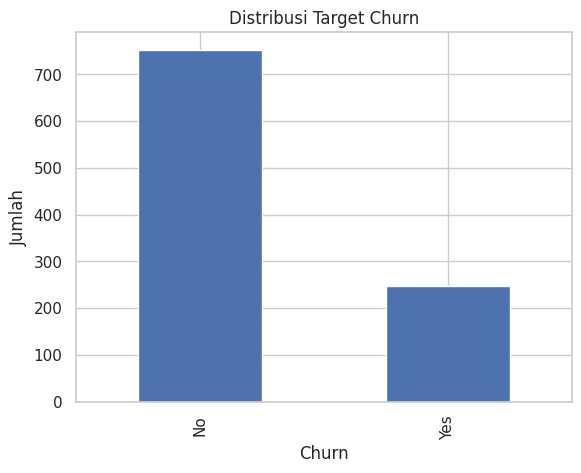

In [3]:
df = df.copy()

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

target_col = "Churn"
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("Distribusi Churn:")
display(df[target_col].value_counts())
display((df[target_col].value_counts(normalize=True) * 100).round(2))

df[target_col].value_counts().plot(kind="bar")
plt.title("Distribusi Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah")
plt.show()

## 4. Preprocessing


In [4]:
df = df.dropna().copy()

y = df[target_col].map({"No": 0, "Yes": 1})
X = df.drop(columns=[target_col])

# Hapus customerID jika ada karena hanya identifier
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Kolom numerik:", num_cols)
print("Kolom kategorikal:", cat_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", [])
    ],
    remainder="drop"
)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Kolom numerik: ['tenure', 'MonthlyCharges']
Kolom kategorikal: ['Contract', 'InternetService', 'PaymentMethod']


X_train: (800, 9)
X_test: (200, 9)


## 5. Random Forest Baseline dan Balanced


In [5]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)
rf_base.fit(X_train, y_train)
pred_base = rf_base.predict(X_test)
proba_base = rf_base.predict_proba(X_test)[:, 1]

rf_bal = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_bal.fit(X_train, y_train)
pred_bal = rf_bal.predict(X_test)
proba_bal = rf_bal.predict_proba(X_test)[:, 1]


print("Model Random Forest baseline dan balanced selesai dilatih.")

Model Random Forest baseline dan balanced selesai dilatih.


## 6. Evaluasi Model


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest Baseline,0.700,0.296,0.163,0.211,0.512,0.285
1,Random Forest Balanced,0.705,0.308,0.163,0.213,0.531,0.277



 Random Forest Baseline
              precision    recall  f1-score   support

    No Churn       0.76      0.87      0.81       151
       Churn       0.30      0.16      0.21        49

    accuracy                           0.70       200
   macro avg       0.53      0.52      0.51       200
weighted avg       0.65      0.70      0.67       200



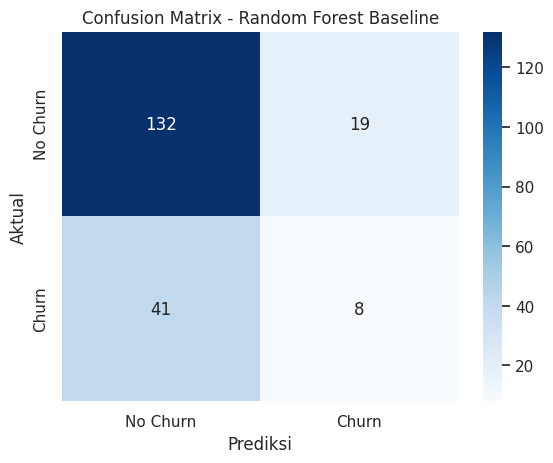


 Random Forest Balanced
              precision    recall  f1-score   support

    No Churn       0.76      0.88      0.82       151
       Churn       0.31      0.16      0.21        49

    accuracy                           0.70       200
   macro avg       0.54      0.52      0.52       200
weighted avg       0.65      0.70      0.67       200



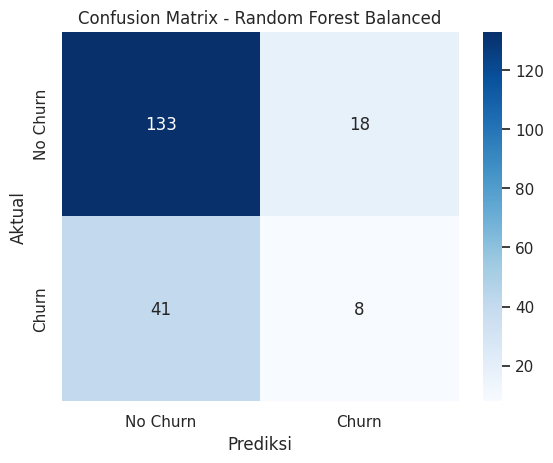

In [6]:
def eval_model(y_true, y_pred, y_proba, nama):
    return {
        "Model": nama,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

hasil = pd.DataFrame([
    eval_model(y_test, pred_base, proba_base, "Random Forest Baseline"),
    eval_model(y_test, pred_bal, proba_bal, "Random Forest Balanced")
])

display(hasil.round(3))

for nama_model, pred in [
    ("Random Forest Baseline", pred_base),
    ("Random Forest Balanced", pred_bal)
]:
    print("\n", nama_model)
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"], zero_division=0))
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    plt.title("Confusion Matrix - " + nama_model)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()


## 7. Threshold Tuning dan Feature Importance


Evaluasi Random Forest Balanced dengan threshold 0.35:
              precision    recall  f1-score   support

    No Churn       0.76      0.75      0.76       151
       Churn       0.26      0.27      0.26        49

    accuracy                           0.64       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.64      0.64      0.64       200



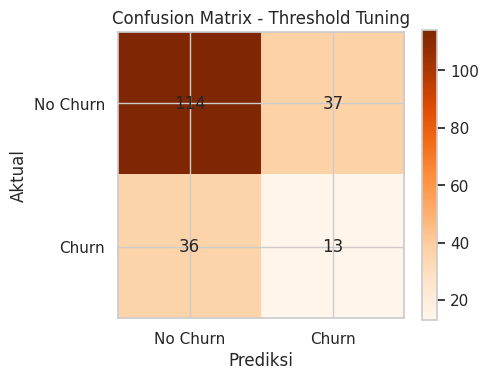

,fitur,importance
1,MonthlyCharges,0.423142
0,tenure,0.368141
2,Contract_One year,0.033984
4,InternetService_Fiber optic,0.033851
5,InternetService_No,0.032330
7,PaymentMethod_Electronic check,0.027937
6,PaymentMethod_Credit card,0.027647
8,PaymentMethod_Mailed check,0.027423
3,Contract_Two year,0.025545


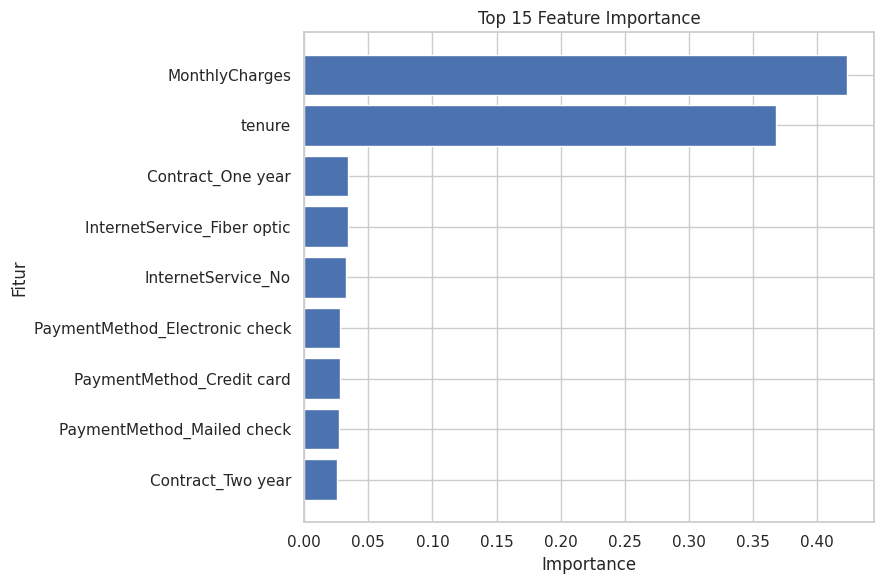

In [7]:
threshold = 0.35
pred_threshold = (proba_bal >= threshold).astype(int)

print(f"Evaluasi Random Forest Balanced dengan threshold {threshold}:")
print(classification_report(y_test, pred_threshold, target_names=["No Churn", "Churn"], zero_division=0))

cm = confusion_matrix(y_test, pred_threshold)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Oranges")
plt.title("Confusion Matrix - Threshold Tuning")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

importance = pd.DataFrame({
    "fitur": X_train.columns,
    "importance": rf_bal.feature_importances_
}).sort_values("importance", ascending=False).head(15)

display(importance)

plt.figure(figsize=(9, 6))
plt.barh(importance["fitur"][::-1], importance["importance"][::-1])
plt.title("Top 15 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## 8. Interpretasi Metrik

Pada customer churn, **Recall** dan **F1-Score** lebih relevan daripada accuracy saja. Dataset churn biasanya imbalanced, sehingga model bisa terlihat memiliki accuracy tinggi hanya karena lebih sering menebak pelanggan tidak churn. Recall penting agar perusahaan dapat menemukan pelanggan yang berisiko churn sebanyak mungkin, sedangkan F1-Score membantu menilai keseimbangan antara precision dan recall.


## Kesimpulan

Saya mempelajari Random Forest dan penanganan imbalanced dataset. Temuan utama adalah accuracy saja bisa menyesatkan pada kasus customer churn, sehingga recall dan F1-Score lebih penting. Keterbatasannya, dataset publik atau fallback sintetis mungkin belum sepenuhnya mewakili kondisi bisnis nyata.
